In [4]:
!mamba install pandas numpy matplotlib
!mamba install statsmodels

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.916 seconds
All requested packages already installed.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, statsmodels
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.136 seconds
  Name         Version  Build                Channel
------------------------------------------------------------------
+ patsy        1.0.3    py313h1804a44_0      emscripten-forge-4x
+ statsmodels  0.14.6   np23py313hd8db738_2  emscripten-forge-4x


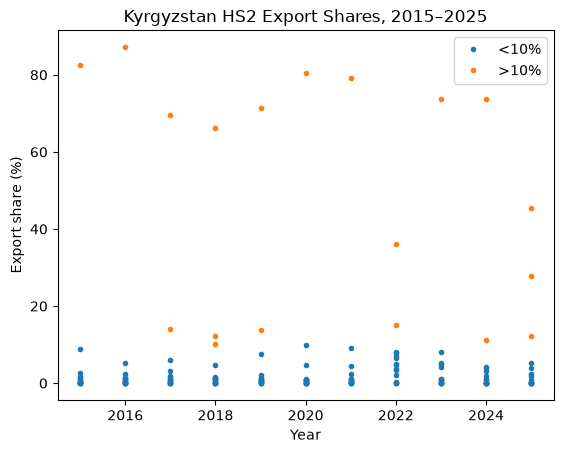

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Kyrgyzstan_Trade_Top30_Products_Each_Year_2015_2025_CONNECTED.csv")

df["hs2"] = df["product"].str.extract(r"^(\d{2})")[0]
df = df.dropna(subset=["hs2"])

x = df.groupby(["year","hs2"])["export_value_m_usd"].sum().reset_index()
x["total"] = x.groupby("year")["export_value_m_usd"].transform("sum")
x["share"] = x["export_value_m_usd"] / x["total"]

# Products with export share above 10% / below 10%
x["status"] = x["share"].apply(lambda v: ">10%" if v > .10 else "<10%")

for s, g in x.groupby("status"):
    plt.plot(g["year"], g["share"]*100, ".", label=s)

plt.xlabel("Year")
plt.ylabel("Export share (%)")
plt.title("Kyrgyzstan HS2 Export Shares, 2015–2025")
plt.legend()
plt.show()

## REGRESSION

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [7]:

df = pd.read_csv('Top30_Countries.csv')

df.head()

,id,country_id,country,year,import_value_m_usd,export_value_m_usd
0,1,2,Russian Federation,2015,1271.64,157.30
1,2,1,China,2015,1029.11,35.88
2,3,3,Kazakhstan,2015,678.26,227.70
3,4,8,Switzerland,2015,18.33,562.11
4,5,4,European Union,2015,307.06,48.29


In [8]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Years:", sorted(df["year"].unique()))

Rows: 330
Columns: ['id', 'country_id', 'country', 'year', 'import_value_m_usd', 'export_value_m_usd']
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [11]:
annual = (
    df.groupby("year", as_index=False)
      .agg(
          exports_m_usd=("export_value_m_usd", "sum"),
          imports_m_usd=("import_value_m_usd", "sum")
      )
)

print(annual)

    year  exports_m_usd  imports_m_usd
0   2015        1390.88        4000.46
1   2016        1407.95        3775.06
2   2017        1738.73        4431.49
3   2018        1816.99        5236.62
4   2019        1959.92        4846.78
5   2020        1838.17        3337.41
6   2021        1614.99        5506.24
7   2022        2200.86        9669.40
8   2023        3310.90       12208.46
9   2024        3647.38       11618.85
10  2025        2564.11       11802.63


In [12]:
annual.describe()

,year,exports_m_usd,imports_m_usd
count,11.000000,11.000000,11.000000
mean,2020.000000,2135.534545,6948.490909
std,3.316625,747.539422,3577.849477
min,2015.000000,1390.880000,3337.410000
25%,2017.500000,1676.860000,4215.975000
50%,2020.000000,1838.170000,5236.620000
75%,2022.500000,2382.485000,10644.125000
max,2025.000000,3647.380000,12208.460000


### EXPORT REGRESSION

In [13]:
X = sm.add_constant(annual["year"])
y = annual["exports_m_usd"]

export_model = sm.OLS(y, X).fit()

print(export_model.summary())

                            OLS Regression Results                            
Dep. Variable:          exports_m_usd   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     16.59
Date:                Mon, 05 Oct 2026   Prob (F-statistic):            0.00279
Time:                        15:04:45   Log-Likelihood:                -82.121
No. Observations:                  11   AIC:                             168.2
Df Residuals:                       9   BIC:                             169.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.645e+05      9e+04     -4.050      0.0

In [15]:
export_coefficient = export_model.params["year"]
export_r2 = export_model.rsquared
export_pvalue = export_model.pvalues["year"]

print("EXPORT REGRESSION")
print("-----------------")
print(f"Coefficient: {export_coefficient:.2f} million USD/year")
print(f"R²: {export_r2:.3f}")
print(f"p-value: {export_pvalue:.4f}")

EXPORT REGRESSION
-----------------
Coefficient: 181.48 million USD/year
R²: 0.648
p-value: 0.0028


###   IMPORT REGRESSION

In [16]:
X = sm.add_constant(annual["year"])
y = annual["imports_m_usd"]

import_model = sm.OLS(y, X).fit()

print(import_model.summary())

                            OLS Regression Results                            
Dep. Variable:          imports_m_usd   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     28.03
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           0.000497
Time:                        15:06:33   Log-Likelihood:                -97.312
No. Observations:                  11   AIC:                             198.6
Df Residuals:                       9   BIC:                             199.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.889e+06   3.58e+05     -5.275      0.0

In [17]:
import_coefficient = import_model.params["year"]
import_r2 = import_model.rsquared
import_pvalue = import_model.pvalues["year"]

print("IMPORT REGRESSION")
print("-----------------")
print(f"Coefficient: {import_coefficient:.2f} million USD/year")
print(f"R²: {import_r2:.3f}")
print(f"p-value: {import_pvalue:.4f}")

IMPORT REGRESSION
-----------------
Coefficient: 938.56 million USD/year
R²: 0.757
p-value: 0.0005


### EXPORT REGRESSION CHART


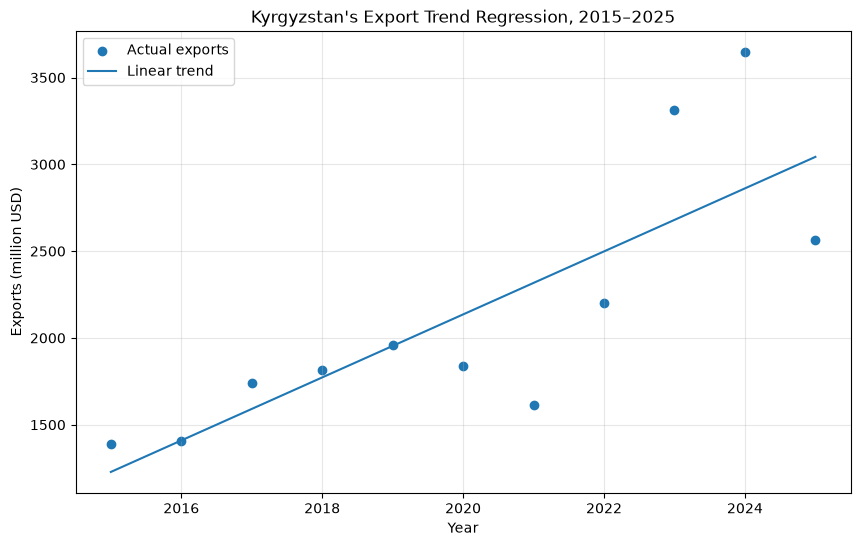

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    annual["year"],
    annual["exports_m_usd"],
    label="Actual exports"
)

plt.plot(
    annual["year"],
    export_model.predict(sm.add_constant(annual["year"])),
    label="Linear trend"
)

plt.xlabel("Year")
plt.ylabel("Exports (million USD)")
plt.title("Kyrgyzstan's Export Trend Regression, 2015–2025")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### IMPORT REGRESSION CHART

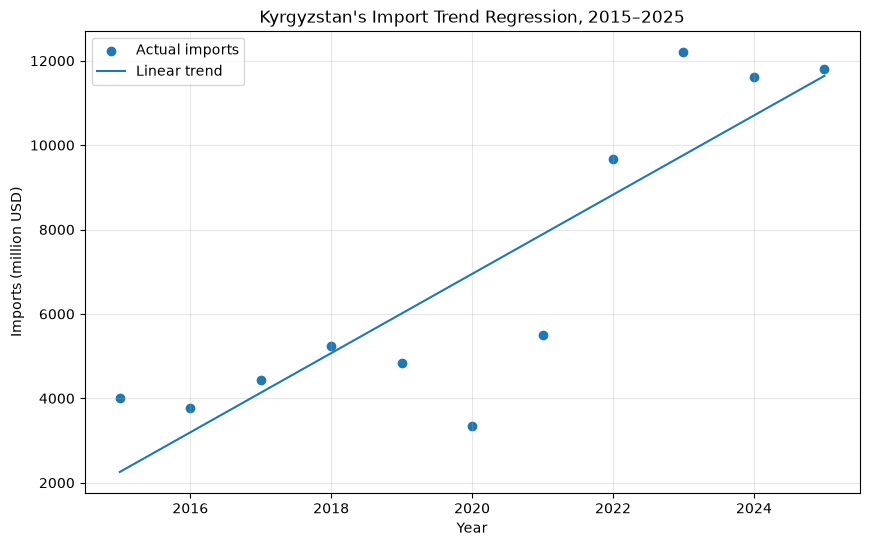

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    annual["year"],
    annual["imports_m_usd"],
    label="Actual imports"
)

plt.plot(
    annual["year"],
    import_model.predict(sm.add_constant(annual["year"])),
    label="Linear trend"
)

plt.xlabel("Year")
plt.ylabel("Imports (million USD)")
plt.title("Kyrgyzstan's Import Trend Regression, 2015–2025")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## FINAL RESULT

In [20]:
regression_results = pd.DataFrame({
    "Dependent variable": ["Exports", "Imports"],
    "Coefficient (million USD/year)": [
        export_coefficient,
        import_coefficient
    ],
    "R²": [
        export_r2,
        import_r2
    ],
    "p-value": [
        export_pvalue,
        import_pvalue
    ]
})

regression_results

,Dependent variable,Coefficient (million USD/year),R²,p-value
0,Exports,181.483545,0.648334,0.002785
1,Imports,938.563091,0.756964,0.000497
